[[147   0   0   1   0   0   2]
 [  5  37  44  32  19  38   6]
 [  3   5  89  12  50   7   1]
 [  0   8   9  91   0  30  16]
 [  1   3  29   5  80   7  34]
 [  1  17   3   7   9  88  18]
 [  2  20  15  10  64   8  46]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       150
           1       0.41      0.20      0.27       181
           2       0.47      0.53      0.50       167
           3       0.58      0.59      0.58       154
           4       0.36      0.50      0.42       159
           5       0.49      0.62      0.55       143
           6       0.37      0.28      0.32       165

    accuracy                           0.52      1119
   macro avg       0.52      0.53      0.51      1119
weighted avg       0.51      0.52      0.50      1119

Confusion matrix, without normalization
Normalized confusion matrix


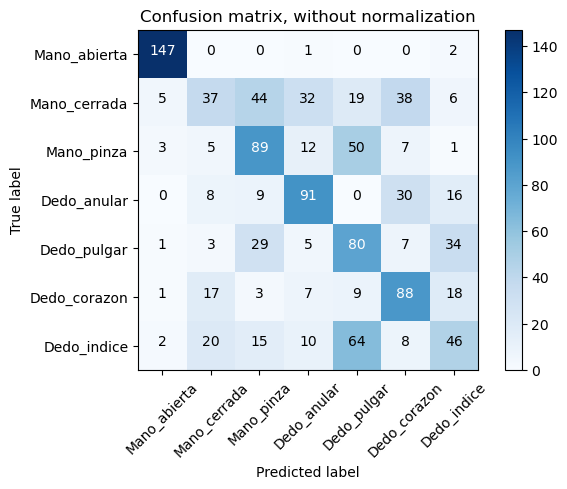

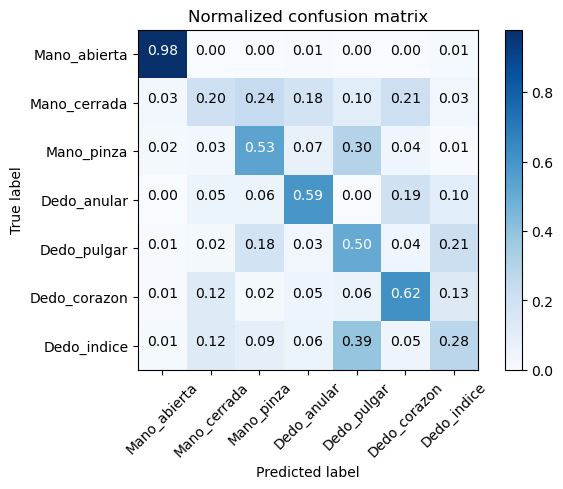

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import matplotlib.pyplot as plt

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZA.csv")
df_cerrada = pd.read_csv("DATASETTOMACERRADA.csv")
df_anular = pd.read_csv("DATASETTOMAANULAR.csv")
df_pulgar = pd.read_csv("DATASETTOMAPULGAR.csv")
df_corazon = pd.read_csv("DATASETTOMACORAZON.csv")
df_indice = pd.read_csv("DATASETTOMAINDICE.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTA.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_cerrada['MAV_total'], 
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_pulgar['MAV_total'], 
    df_corazon['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_cerrada['VAR_total'], 
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_pulgar['VAR_total'], 
    df_corazon['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_cerrada['RMS_total'], 
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_pulgar['RMS_total'], 
    df_corazon['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

abs_df["Wav_Leng"] = pd.concat([
    df_cerrada['Wav_Leng'], 
    df_pinza['Wav_Leng'], 
    df_anular['Wav_Leng'], 
    df_pulgar['Wav_Leng'], 
    df_corazon['Wav_Leng'], 
    df_indice['Wav_Leng'], 
    df_abierta['Wav_Leng']
], axis=0).reset_index(drop=True)

abs_df["Dasdv"] = pd.concat([
    df_cerrada['Dasdv'], 
    df_pinza['Dasdv'], 
    df_anular['Dasdv'], 
    df_pulgar['Dasdv'], 
    df_corazon['Dasdv'], 
    df_indice['Dasdv'], 
    df_abierta['Dasdv']
], axis=0).reset_index(drop=True)

abs_df["Damv"] = pd.concat([
    df_cerrada['Damv'], 
    df_pinza['Damv'], 
    df_anular['Damv'], 
    df_pulgar['Damv'], 
    df_corazon['Damv'], 
    df_indice['Damv'], 
    df_abierta['Damv']
], axis=0).reset_index(drop=True)

abs_df["iav"] = pd.concat([
    df_cerrada['iav'], 
    df_pinza['iav'], 
    df_anular['iav'], 
    df_pulgar['iav'], 
    df_corazon['iav'], 
    df_indice['iav'], 
    df_abierta['iav']
], axis=0).reset_index(drop=True)

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_cerrada['Mano_cerrada'].apply(lambda x: 1),
    df_pinza['Mano_pinza'].apply(lambda x: 2),
    df_anular['Dedo_anular'].apply(lambda x: 3),
    df_pulgar['Dedo_pulgar'].apply(lambda x: 4),
    df_corazon['Dedo_corazon'].apply(lambda x: 5),
    df_indice['Dedo_indice'].apply(lambda x: 6),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar el modelo de regresión logística
logreg = LogisticRegression(max_iter=1000, multi_class='ovr')
logreg.fit(X_train, y_train)

# Hacer predicciones
y_pred = logreg.predict(X_test)

# Evaluar el modelo
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    Esta función imprime y dibuja la matriz de confusión.
    La normalización se puede aplicar configurando `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Calcular la matriz de confusión
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plotear la matriz de confusión no normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'],
                      title='Confusion matrix, without normalization')

# Plotear la matriz de confusión normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()


[[216   1   0   1   5   1   1]
 [  0 124  46  44  25  17  20]
 [  2  33 141  11  43   9  11]
 [  0  24  11 161   0  30   1]
 [  1  30  43   5 138   0  22]
 [  0  13   4  30   2 154  16]
 [  0  25  18   5  27   9 158]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       225
           1       0.50      0.45      0.47       276
           2       0.54      0.56      0.55       250
           3       0.63      0.71      0.67       227
           4       0.57      0.58      0.58       239
           5       0.70      0.70      0.70       219
           6       0.69      0.65      0.67       242

    accuracy                           0.65      1678
   macro avg       0.66      0.66      0.66      1678
weighted avg       0.65      0.65      0.65      1678

Confusion matrix, without normalization
Normalized confusion matrix


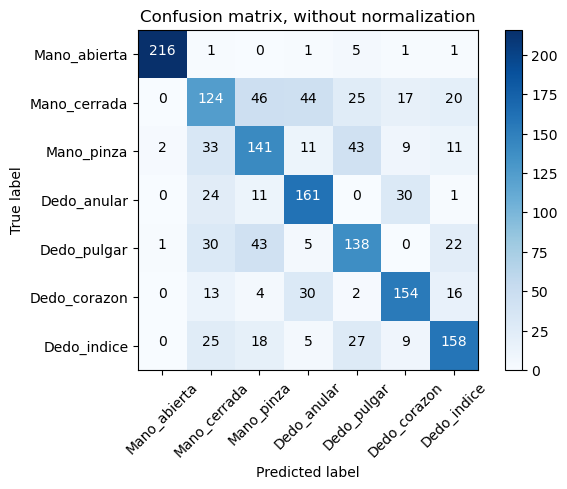

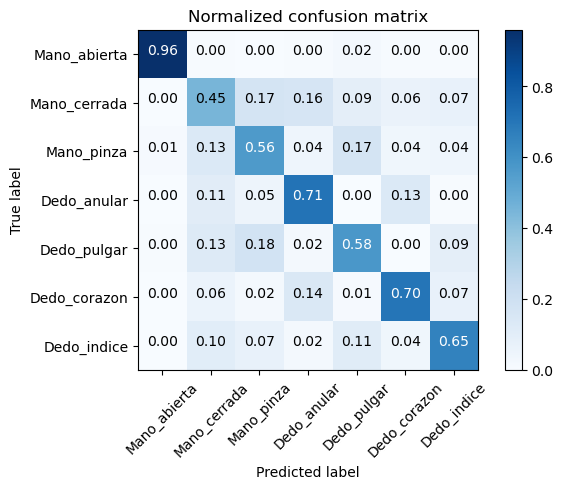

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import matplotlib.pyplot as plt

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZA.csv")
df_cerrada = pd.read_csv("DATASETTOMACERRADA.csv")
df_anular = pd.read_csv("DATASETTOMAANULAR.csv")
df_pulgar = pd.read_csv("DATASETTOMAPULGAR.csv")
df_corazon = pd.read_csv("DATASETTOMACORAZON.csv")
df_indice = pd.read_csv("DATASETTOMAINDICE.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTA.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_cerrada['MAV_total'], 
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_pulgar['MAV_total'], 
    df_corazon['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_cerrada['VAR_total'], 
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_pulgar['VAR_total'], 
    df_corazon['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_cerrada['RMS_total'], 
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_pulgar['RMS_total'], 
    df_corazon['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

abs_df["Wav_Leng"] = pd.concat([
    df_cerrada['Wav_Leng'], 
    df_pinza['Wav_Leng'], 
    df_anular['Wav_Leng'], 
    df_pulgar['Wav_Leng'], 
    df_corazon['Wav_Leng'], 
    df_indice['Wav_Leng'], 
    df_abierta['Wav_Leng']
], axis=0).reset_index(drop=True)

abs_df["Dasdv"] = pd.concat([
    df_cerrada['Dasdv'], 
    df_pinza['Dasdv'], 
    df_anular['Dasdv'], 
    df_pulgar['Dasdv'], 
    df_corazon['Dasdv'], 
    df_indice['Dasdv'], 
    df_abierta['Dasdv']
], axis=0).reset_index(drop=True)

abs_df["Damv"] = pd.concat([
    df_cerrada['Damv'], 
    df_pinza['Damv'], 
    df_anular['Damv'], 
    df_pulgar['Damv'], 
    df_corazon['Damv'], 
    df_indice['Damv'], 
    df_abierta['Damv']
], axis=0).reset_index(drop=True)

abs_df["iav"] = pd.concat([
    df_cerrada['iav'], 
    df_pinza['iav'], 
    df_anular['iav'], 
    df_pulgar['iav'], 
    df_corazon['iav'], 
    df_indice['iav'], 
    df_abierta['iav']
], axis=0).reset_index(drop=True)

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_cerrada['Mano_cerrada'].apply(lambda x: 1),
    df_pinza['Mano_pinza'].apply(lambda x: 2),
    df_anular['Dedo_anular'].apply(lambda x: 3),
    df_pulgar['Dedo_pulgar'].apply(lambda x: 4),
    df_corazon['Dedo_corazon'].apply(lambda x: 5),
    df_indice['Dedo_indice'].apply(lambda x: 6),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar el modelo k-NN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Hacer predicciones
y_pred = knn.predict(X_test)

# Evaluar el modelo
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    Esta función imprime y dibuja la matriz de confusión.
    La normalización se puede aplicar configurando `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Calcular la matriz de confusión
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plotear la matriz de confusión no normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'],
                      title='Confusion matrix, without normalization')

# Plotear la matriz de confusión normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()


[[143   0   1   3   0   0   3]
 [  0  64  35  22  29  19  12]
 [  2  27  82   7  39   5   5]
 [  2  21   7  92   1  27   4]
 [  2  23  29   4  84   0  17]
 [  0  14   6  25   3  86   9]
 [  2  22   7   4  18   7 105]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       150
           1       0.37      0.35      0.36       181
           2       0.49      0.49      0.49       167
           3       0.59      0.60      0.59       154
           4       0.48      0.53      0.50       159
           5       0.60      0.60      0.60       143
           6       0.68      0.64      0.66       165

    accuracy                           0.59      1119
   macro avg       0.59      0.59      0.59      1119
weighted avg       0.59      0.59      0.59      1119

Confusion matrix, without normalization
Normalized confusion matrix


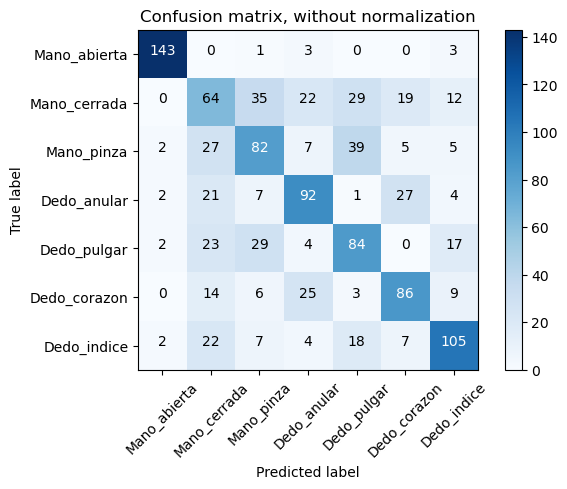

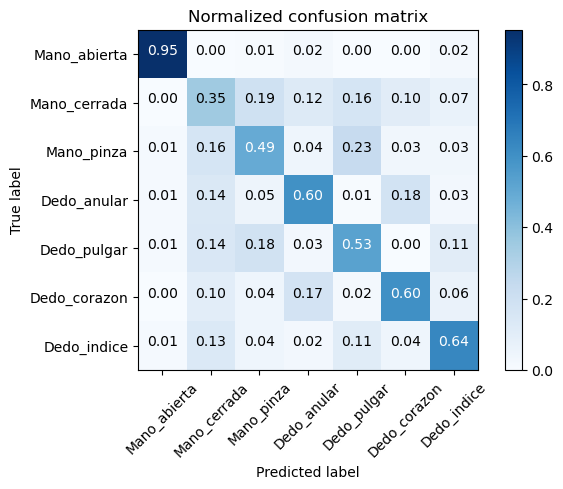

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import matplotlib.pyplot as plt

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    Esta función imprime y dibuja la matriz de confusión.
    La normalización se puede aplicar configurando `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZA.csv")
df_cerrada = pd.read_csv("DATASETTOMACERRADA.csv")
df_anular = pd.read_csv("DATASETTOMAANULAR.csv")
df_pulgar = pd.read_csv("DATASETTOMAPULGAR.csv")
df_corazon = pd.read_csv("DATASETTOMACORAZON.csv")
df_indice = pd.read_csv("DATASETTOMAINDICE.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTA.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_cerrada['MAV_total'], 
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_pulgar['MAV_total'], 
    df_corazon['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_cerrada['VAR_total'], 
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_pulgar['VAR_total'], 
    df_corazon['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_cerrada['RMS_total'], 
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_pulgar['RMS_total'], 
    df_corazon['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

abs_df["Wav_Leng"] = pd.concat([
    df_cerrada['Wav_Leng'], 
    df_pinza['Wav_Leng'], 
    df_anular['Wav_Leng'], 
    df_pulgar['Wav_Leng'], 
    df_corazon['Wav_Leng'], 
    df_indice['Wav_Leng'], 
    df_abierta['Wav_Leng']
], axis=0).reset_index(drop=True)

abs_df["Dasdv"] = pd.concat([
    df_cerrada['Dasdv'], 
    df_pinza['Dasdv'], 
    df_anular['Dasdv'], 
    df_pulgar['Dasdv'], 
    df_corazon['Dasdv'], 
    df_indice['Dasdv'], 
    df_abierta['Dasdv']
], axis=0).reset_index(drop=True)

abs_df["Damv"] = pd.concat([
    df_cerrada['Damv'], 
    df_pinza['Damv'], 
    df_anular['Damv'], 
    df_pulgar['Damv'], 
    df_corazon['Damv'], 
    df_indice['Damv'], 
    df_abierta['Damv']
], axis=0).reset_index(drop=True)

abs_df["iav"] = pd.concat([
    df_cerrada['iav'], 
    df_pinza['iav'], 
    df_anular['iav'], 
    df_pulgar['iav'], 
    df_corazon['iav'], 
    df_indice['iav'], 
    df_abierta['iav']
], axis=0).reset_index(drop=True)

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_cerrada['Mano_cerrada'].apply(lambda x: 1),
    df_pinza['Mano_pinza'].apply(lambda x: 2),
    df_anular['Dedo_anular'].apply(lambda x: 3),
    df_pulgar['Dedo_pulgar'].apply(lambda x: 4),
    df_corazon['Dedo_corazon'].apply(lambda x: 5),
    df_indice['Dedo_indice'].apply(lambda x: 6),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar el modelo de árbol de decisiones
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Hacer predicciones
y_pred = tree.predict(X_test)

# Evaluar el modelo
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Calcular la matriz de confusión
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plotear la matriz de confusión no normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'],
                      title='Confusion matrix, without normalization')

# Plotear la matriz de confusión normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'], 
                      normalize=True,
                      title='Normalized confusion matrix')

plt.show()


[[139   0   0   3   8   0   0]
 [  0  20  22  39  41  48  11]
 [  3   6  22  39  66  26   5]
 [  0   3   2  80   0  52  17]
 [  0   0   8  29  97   1  24]
 [  0  13   2  36   3  45  44]
 [  0   7   9  20  39   7  83]]
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       150
           1       0.41      0.11      0.17       181
           2       0.34      0.13      0.19       167
           3       0.33      0.52      0.40       154
           4       0.38      0.61      0.47       159
           5       0.25      0.31      0.28       143
           6       0.45      0.50      0.48       165

    accuracy                           0.43      1119
   macro avg       0.45      0.45      0.42      1119
weighted avg       0.45      0.43      0.41      1119

Confusion matrix, without normalization
Normalized confusion matrix


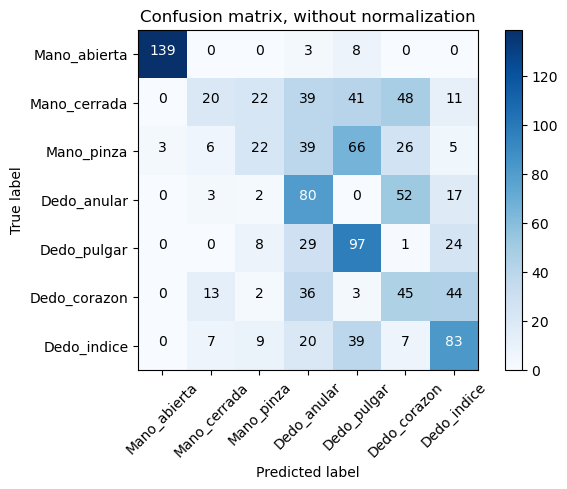

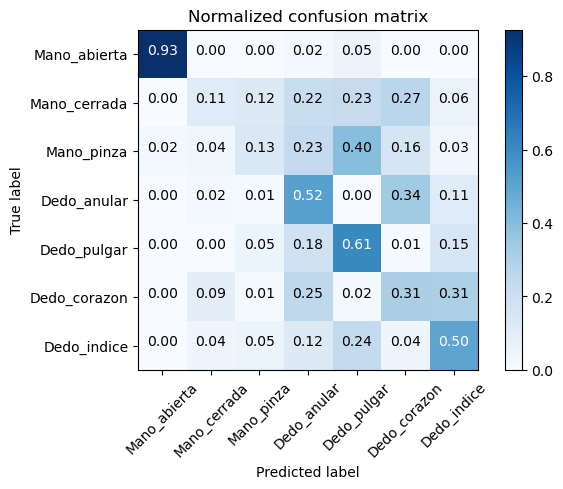

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import matplotlib.pyplot as plt

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZA.csv")
df_cerrada = pd.read_csv("DATASETTOMACERRADA.csv")
df_anular = pd.read_csv("DATASETTOMAANULAR.csv")
df_pulgar = pd.read_csv("DATASETTOMAPULGAR.csv")
df_corazon = pd.read_csv("DATASETTOMACORAZON.csv")
df_indice = pd.read_csv("DATASETTOMAINDICE.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTA.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_cerrada['MAV_total'], 
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_pulgar['MAV_total'], 
    df_corazon['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_cerrada['VAR_total'], 
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_pulgar['VAR_total'], 
    df_corazon['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_cerrada['RMS_total'], 
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_pulgar['RMS_total'], 
    df_corazon['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_cerrada['Mano_cerrada'].apply(lambda x: 1),
    df_pinza['Mano_pinza'].apply(lambda x: 2),
    df_anular['Dedo_anular'].apply(lambda x: 3),
    df_pulgar['Dedo_pulgar'].apply(lambda x: 4),
    df_corazon['Dedo_corazon'].apply(lambda x: 5),
    df_indice['Dedo_indice'].apply(lambda x: 6),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar el modelo de Máquina de Soporte Vectorial (SVM)
svm = SVC(random_state=42)
svm.fit(X_train, y_train)

# Hacer predicciones
y_pred = svm.predict(X_test)

# Evaluar el modelo
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Calcular la matriz de confusión
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plotear la matriz de confusión no normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'],
                      title='Confusion matrix, without normalization')

# Plotear la matriz de confusión normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'], 
                      normalize=True,
                      title='Normalized confusion matrix')

plt.show()
